# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Exploring Hypothesis 1

---
## Foreword

In this notebook, my goal is to explore this hypothesis:

$$
\mathbb{E}[\Delta\textit{users\_close}_{i, t + 1} \mid \text{high}(ASVI_{i, t})] \ge 0
$$

where $ASVI_{i, t}$ translates abnormal volume in Google Trends. In other words, the purpose of this hypothesis is to explore whether lagged attention spikes in Google Trends can predict an increase in the number of Robinhood users holding a stock $i$ at time $t+1$. Additionally, I will also focus on the following question: "Among competing attention proxies, which ones contain incremental information about next-day retail demand on Robinhood?"


## 1. Libraries & Data

I first load the relevant libraries and data.

In [2]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels import OLS
from linearmodels.panel import PanelOLS

In [3]:
# data
main = pd.read_csv("../../../data/processed/herding_events_full.csv")

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/2964944586.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  main = pd.read_csv("../../../data/processed/herding_events_full.csv")


Once I loaded the data, I parse the date accordingly.

In [4]:
# date format
main["date"] = pd.to_datetime(main["date"])

## 2. Exploratory Data Analysis

In this section, I conduct a brief EDA.

In [5]:
# the columns
main.columns

Index(['date', 'users_close', 'users_open', 'users_last', 'intraday_userchg',
       'ticker', 'permno', 'ret', 'prc', 'vol', 'shrout', 'exchcd', 'symro',
       'symsu', 'buy_num_trades_LR', 'sell_num_trades_LR', 'total_trade_LR',
       'buy_vol_LR', 'sell_vol_LR', 'total_vol_LR', 'close_price',
       'open_price', 'close_vol', 'open_vol', 'total_vol_m', 'intra_ret',
       'buy_num_trades_tick', 'sell_num_trades_tick', 'buy_vol_tick',
       'sell_vol_tick', 'total_trade_tick', 'buy_num_trades_wrds',
       'sell_num_trades_wrds', 'buy_vol_wrds', 'sell_vol_wrds',
       'total_trade_wrds', 'bs_ratio_num', 'bs_ratio_vol',
       'buy_num_trades_retail', 'sell_num_trades_retail', 'buy_vol_retail',
       'sell_vol_retail', 'total_trade_retail', 'total_vol_retail',
       'bs_ratio_retail_vol', 'bs_ratio_retail_num', 'intra_volatility',
       'buy_num_trades_inst50k', 'sell_num_trades_inst50k', 'buy_vol_inst50k',
       'sell_vol_inst50k', 'total_trade_inst50k', 'total_vol_inst50k',


In [6]:
# number of non-nan rows with svi and number of unique tickers in those rows
print(f"Number of non-nan rows with svi: {main['svi'].notna().sum()}")
print(f"Number of unique tickers in those rows: {main[main['date'].notna() & main['svi'].notna()]['ticker'].nunique()}")

Number of non-nan rows with svi: 1138630
Number of unique tickers in those rows: 2179


In [7]:
# shape, number of unique tickers
print(f"Shape of the dataset: {main.shape}")
print(f"Number of unique tickers: {main['ticker'].nunique()}")

Shape of the dataset: (1178991, 74)
Number of unique tickers: 2179


In [8]:
# number of unique tickers with non-nan ess, css, and anl_chg
print(f"Number of unique tickers with non-nan ess: {main[main['ess'].notna()]['ticker'].nunique()}")
print(f"Number of unique tickers with non-nan css: {main[main['css'].notna()]['ticker'].nunique()}")
print(f"Number of unique tickers with non-nan anl_chg: {main[main['anl_chg'].notna()]['ticker'].nunique()}")

Number of unique tickers with non-nan ess: 1626
Number of unique tickers with non-nan css: 1640
Number of unique tickers with non-nan anl_chg: 1640


## 3. Regressions

### 3.1. Basline Regression (Abnormal Volume and Returns)

The first regression is specifed as follows.

**Dependent Variable**

$$
\Delta \textit{users\_close}_{i, t} = {\textit{users\_close}_{i, t} - \textit{users\_close}_{i, t -1}}
$$

In [9]:
# select only relevant variables
df_reg_1 = main[['date', 'ticker', 'users_close', 'userchg', 'intraday_userchg', 'net_buys', 'ret', 'vol',
                 'svi', 'num_news', 'ess', 'css', 'anl_chg', 'num_news_relevant', 'asvi']].copy()

# replace nan values in num_news, num_news_relevant, ess, css, and anl_chg with 0 (assuming no news and no analyst changes if missing)
df_reg_1['num_news'].fillna(0, inplace=True)
df_reg_1['num_news_relevant'].fillna(0, inplace=True)
df_reg_1['ess'].fillna(0, inplace=True)
df_reg_1['css'].fillna(0, inplace=True)
df_reg_1['anl_chg'].fillna(0, inplace=True)

# sort by ticker and date
df_reg_1.sort_values(by=['ticker', 'date'], inplace=True)

# drop rows with missing raw inputs
df_reg_1.dropna(subset=['users_close', 'userchg', 'ret', 'vol'], inplace=True)

# ln userchg
df_reg_1['ln_userchg'] = np.log(1 + np.abs(df_reg_1['userchg']))

# ab_ret_lag1
def make_ab_ret(s):
    lags = pd.concat([s.shift(k) for k in range(2, 22)], axis=1)
    mu = lags.mean(axis=1)
    sigma = lags.std(axis=1)
    z = (s.shift(1) - mu) / sigma
    z[sigma == 0] = np.nan
    return z

df_reg_1["ab_ret_lag1"] = df_reg_1.groupby("ticker")["ret"].transform(make_ab_ret)

# ret(t - 1)
df_reg_1['ret_lag1'] = df_reg_1.groupby('ticker')['ret'].shift(1)

# binary indicator for ret(t - 1) in the top 20 of the absolute returns. 
# if ret(t - 1) is in the top 20 of the absolute returns, then ab_ret_lag1 is 1, otherwise 0.
df_reg_1['top_20'] = (df_reg_1['ret_lag1'].abs() >= df_reg_1.groupby('ticker')['ret'].transform(lambda x: x.abs().nlargest(20).min())).astype(int)

# ab_vol_lag1
def make_ab_vol(s):
    lags = pd.concat([s.shift(k) for k in range(2, 22)], axis=1)
    mu = lags.mean(axis=1)
    ratio = s.shift(1) / mu
    ratio[mu == 0] = np.nan
    return np.log1p(np.abs(ratio))

df_reg_1["ab_vol_lag1"] = df_reg_1.groupby("ticker")["vol"].transform(make_ab_vol)

# lagged ess, css, and anl_chg
df_reg_1['ess_lag1'] = df_reg_1.groupby('ticker')['ess'].shift(1)
df_reg_1['css_lag1'] = df_reg_1.groupby('ticker')['css'].shift(1)
df_reg_1['anl_chg_lag1'] = df_reg_1.groupby('ticker')['anl_chg'].shift(1)

# lagged net_buys
df_reg_1['net_buys_lag1'] = df_reg_1.groupby('ticker')['net_buys'].shift(1)

# optional cleanup
df_reg_1.replace([np.inf, -np.inf], np.nan, inplace=True)

# dimensions and head
print(f"Shape of the regression dataset: {df_reg_1.shape}")

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/1495885197.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_reg_1['num_news'].fillna(0, inplace=True)
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/1495885197.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

Shape of the regression dataset: (1053730, 24)


In [10]:
# missing values in the regression dataset
missing_values = df_reg_1.isna().sum()
print("Missing values in the regression dataset:")
print(missing_values)

Missing values in the regression dataset:
date                     0
ticker                   0
users_close              0
userchg                  0
intraday_userchg      3792
net_buys              5331
ret                      0
vol                      0
svi                  32514
num_news                 0
ess                      0
css                      0
anl_chg                  0
num_news_relevant        0
asvi                 68740
ln_userchg               0
ab_ret_lag1           5940
ret_lag1              1979
top_20                   0
ab_vol_lag1           3959
ess_lag1              1979
css_lag1              1979
anl_chg_lag1          1979
net_buys_lag1         7298
dtype: int64


In [11]:
# fill missing svi with 0 (assuming no search interest if missing)
df_reg_1['svi'].fillna(0, inplace=True)
df_reg_1['asvi'].fillna(0, inplace=True)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/1078527374.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_reg_1['svi'].fillna(0, inplace=True)
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/1078527374.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [12]:
# reg data
reg1 = df_reg_1.copy().dropna(subset=['userchg', 'top_20', 'ab_vol_lag1', 'asvi'])

# make sure date is datetime
reg1['date'] = pd.to_datetime(reg1['date'])

# convert clusters to integer codes
reg1['ticker_clust'] = reg1['ticker'].astype('category').cat.codes
reg1['date_clust'] = reg1['date'].astype('category').cat.codes

X1 = sm.add_constant(reg1[['top_20', 'ab_vol_lag1', 'asvi']])
y1 = reg1['userchg']

results1 = OLS(y1, X1).fit(
    cov_type='clustered',
    clusters=reg1[['ticker_clust', 'date_clust']]
)

print(results1.summary)

                            OLS Estimation Summary                            
Dep. Variable:                userchg   R-squared:                      0.0061
Estimator:                        OLS   Adj. R-squared:                 0.0061
No. Observations:             1049771   F-statistic:                    51.208
Date:                Sun, Mar 29 2026   P-value (F-stat)                0.0000
Time:                        00:31:22   Distribution:                  chi2(3)
Cov. Estimator:             clustered                                         
                                                                              
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const          -17.945     4.4189    -4.0611     0.0000     -26.606     -9.2846
top_20          105.75     15.724     6.7253    

With fixed stocks and dates effect:

In [13]:
# reg data
reg1_a = df_reg_1.copy().dropna(subset=['userchg', 'top_20', 'ab_vol_lag1', 'asvi'])

# make sure date is datetime
reg1_a['date'] = pd.to_datetime(reg1_a['date'])

# set panel index: entity = ticker, time = date
reg1_a = reg1_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y1 = reg1_a['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X1 = reg1_a[[
    'top_20', 'ab_vol_lag1', 'asvi'
]]

# fit the model with entity and time fixed effects
model1 = PanelOLS(y1, X1, entity_effects=True, time_effects=True)
results1_fe = model1.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results1_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/3758268124.py:20: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results1_fe = model1.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.0029
Estimator:                   PanelOLS   R-squared (Between):             -0.0392
No. Observations:             1049771   R-squared (Within):               0.0052
Date:                Sun, Mar 29 2026   R-squared (Overall):              0.0037
Time:                        00:31:25   Log-likelihood                -7.534e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1029.0
Entities:                        1979   P-value                           0.0000
Avg Obs:                       530.46   Distribution:               F(3,1047232)
Min Obs:                       2.0000                                           
Max Obs:                       558.00   F-statistic (robust):             14.792
                            

### 3.2. Control for Persistence

In [14]:
# reg data
df_reg_1['userchg_lag1'] = df_reg_1.groupby('ticker')['userchg'].shift(1)
reg2 = df_reg_1.copy().dropna(subset=['userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi'])

# make sure date is datetime
reg2['date'] = pd.to_datetime(reg2['date'])

# convert clusters to integer codes
reg2['ticker_clust'] = reg2['ticker'].astype('category').cat.codes
reg2['date_clust'] = reg2['date'].astype('category').cat.codes

X2 = sm.add_constant(reg2[['top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi']])
y2 = reg2['userchg']

results2 = OLS(y2, X2).fit(
    cov_type='clustered',
    clusters=reg2[['ticker_clust', 'date_clust']]
)

print(results2.summary)

                            OLS Estimation Summary                            
Dep. Variable:                userchg   R-squared:                      0.3960
Estimator:                        OLS   Adj. R-squared:                 0.3960
No. Observations:             1049771   F-statistic:                    332.60
Date:                Sun, Mar 29 2026   P-value (F-stat)                0.0000
Time:                        00:31:29   Distribution:                  chi2(4)
Cov. Estimator:             clustered                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
const            5.5778     1.8791     2.9684     0.0030      1.8949      9.2607
top_20           45.392     8.5867     5.286

Now with fixed effects:

In [15]:
# reg data
df_reg_1['userchg_lag1'] = df_reg_1.groupby('ticker')['userchg'].shift(1)
reg2_a = df_reg_1.copy().dropna(subset=['userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi'])

# make sure date is datetime
reg2_a['date'] = pd.to_datetime(reg2_a['date'])

# set panel index: entity = ticker, time = date
reg2_a = reg2_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y2 = reg2_a['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X2 = reg2_a[[
    'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi'
]]

# fit the model with entity and time fixed effects
model2 = PanelOLS(y2, X2, entity_effects=True, time_effects=True)
results2_fe = model2.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results2_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/973730151.py:21: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results2_fe = model2.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3584
Estimator:                   PanelOLS   R-squared (Between):              0.8467
No. Observations:             1049771   R-squared (Within):               0.3621
Date:                Sun, Mar 29 2026   R-squared (Overall):              0.3960
Time:                        00:31:32   Log-likelihood                -7.303e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.462e+05
Entities:                        1979   P-value                           0.0000
Avg Obs:                       530.46   Distribution:               F(4,1047231)
Min Obs:                       2.0000                                           
Max Obs:                       558.00   F-statistic (robust):             70.436
                            

### 3.3. Control for News 

In [16]:
# reg data
df_reg_1['num_news_lag1'] = df_reg_1.groupby('ticker')['num_news'].shift(1)
df_reg_1['num_news_relevant_lag1'] = df_reg_1.groupby('ticker')['num_news_relevant'].shift(1)
df_reg_1['ess_lag1'] = df_reg_1.groupby('ticker')['ess'].shift(1)
df_reg_1['css_lag1'] = df_reg_1.groupby('ticker')['css'].shift(1)
df_reg_1['anl_chg_lag1'] = df_reg_1.groupby('ticker')['anl_chg'].shift(1)

reg3 = df_reg_1.copy().dropna(subset=['userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi', 'num_news_lag1', 'num_news_relevant_lag1'])

# make sure date is datetime
reg3['date'] = pd.to_datetime(reg3['date'])

# convert clusters to integer codes
reg3['ticker_clust'] = reg3['ticker'].astype('category').cat.codes
reg3['date_clust'] = reg3['date'].astype('category').cat.codes

X3 = sm.add_constant(reg3[['top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi', 'num_news_lag1', 'num_news_relevant_lag1']])
y3 = reg3['userchg']

results3 = OLS(y3, X3).fit(
    cov_type='clustered',
    clusters=reg3[['ticker_clust', 'date_clust']]
)

print(results3.summary)

                            OLS Estimation Summary                            
Dep. Variable:                userchg   R-squared:                      0.3961
Estimator:                        OLS   Adj. R-squared:                 0.3961
No. Observations:             1049771   F-statistic:                    334.90
Date:                Sun, Mar 29 2026   P-value (F-stat)                0.0000
Time:                        00:31:36   Distribution:                  chi2(6)
Cov. Estimator:             clustered                                         
                                                                              
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
const                      5.4253     1.8994     2.8564     0.0043      1.7026      9.1480
top_

And now with fixed effects:

In [17]:
reg3_a = df_reg_1.copy().dropna(subset=['userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi', 'num_news_lag1', 'num_news_relevant_lag1'])

# make sure date is datetime
reg3_a['date'] = pd.to_datetime(reg3_a['date'])

# set panel index: entity = ticker, time = date
reg3_a = reg3_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y3 = reg3_a['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X3 = reg3_a[[
    'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi', 'num_news_lag1', 'num_news_relevant_lag1'
]]

# fit the model with entity and time fixed effects
model3 = PanelOLS(y3, X3, entity_effects=True, time_effects=True)
results3_fe = model3.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results3_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/4006835727.py:19: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results3_fe = model3.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3584
Estimator:                   PanelOLS   R-squared (Between):              0.8448
No. Observations:             1049771   R-squared (Within):               0.3622
Date:                Sun, Mar 29 2026   R-squared (Overall):              0.3959
Time:                        00:31:39   Log-likelihood                -7.302e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   9.752e+04
Entities:                        1979   P-value                           0.0000
Avg Obs:                       530.46   Distribution:               F(6,1047229)
Min Obs:                       2.0000                                           
Max Obs:                       558.00   F-statistic (robust):             47.357
                            

### 3.5. Control for Sentiment

In [18]:
reg4 = df_reg_1.copy().dropna(subset=['userchg', 'top_20', 'ab_vol_lag1',
                                      'userchg_lag1', 'asvi', 'num_news_lag1',
                                      'num_news_relevant_lag1',
                                      'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'intraday_userchg'])

# make sure date is datetime
reg4['date'] = pd.to_datetime(reg4['date'])

# convert clusters to integer codes
reg4['ticker_clust'] = reg4['ticker'].astype('category').cat.codes
reg4['date_clust'] = reg4['date'].astype('category').cat.codes

X4 = sm.add_constant(reg4[['top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi', 'num_news_lag1',
                           'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1' ]])
y4 = reg4['intraday_userchg']

results4 = OLS(y4, X4).fit(
    cov_type='clustered',
    clusters=reg4[['ticker_clust', 'date_clust']]
)

print(results4.summary)

                            OLS Estimation Summary                            
Dep. Variable:       intraday_userchg   R-squared:                      0.1827
Estimator:                        OLS   Adj. R-squared:                 0.1826
No. Observations:             1045981   F-statistic:                    180.30
Date:                Sun, Mar 29 2026   P-value (F-stat)                0.0000
Time:                        00:31:44   Distribution:                  chi2(9)
Cov. Estimator:             clustered                                         
                                                                              
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
const                     -5.2445     2.1290    -2.4633     0.0138     -9.4173     -1.0716
top_

Below is a more robust version with fixed stocks and dates effects.

In [19]:

reg4_a = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg4_a['date'] = pd.to_datetime(reg4_a['date'])

# set panel index: entity = ticker, time = date
reg4_a = reg4_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y4 = reg4_a['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X4 = reg4_a[[
    'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1'
]]

# estimate with stock and date fixed effects
model4 = PanelOLS(
    y4,
    X4,
    entity_effects=True,   # stock fixed effects
    time_effects=True      # date fixed effects
)

results4 = model4.fit(
    cov_type='clustered',
    cluster_entity=True,   # cluster by stock
    cluster_time=True      # cluster by date
)

print(results4.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/1576886623.py:31: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results4 = model4.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3585
Estimator:                   PanelOLS   R-squared (Between):              0.8441
No. Observations:             1049771   R-squared (Within):               0.3622
Date:                Sun, Mar 29 2026   R-squared (Overall):              0.3958
Time:                        00:31:48   Log-likelihood                -7.302e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   6.502e+04
Entities:                        1979   P-value                           0.0000
Avg Obs:                       530.46   Distribution:               F(9,1047226)
Min Obs:                       2.0000                                           
Max Obs:                       558.00   F-statistic (robust):             34.931
                            

One thing that is odd is that when controlling for fixed effects, the sign of `asvi`'s coefficient switch. I will now investigate this.

In [20]:
reg4_b = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg4_b['date'] = pd.to_datetime(reg4_b['date'])

# set panel index: entity = ticker, time = date
reg4_b = reg4_b.set_index(['ticker', 'date']).sort_index()

# dependent variable
y4b = reg4_b['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X4b = reg4_b[[
    'top_20', 'ab_vol_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1'
]]

# estimate with stock and date fixed effects
model4b = PanelOLS(
    y4b,
    X4b,
    entity_effects=True,   # stock fixed effects
    time_effects=True      # date fixed effects
)

results4b = model4b.fit(
    cov_type='clustered',
    cluster_entity=True,   # cluster by stock
    cluster_time=True      # cluster by date
)

print(results4b.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/1121830033.py:31: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results4b = model4b.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.0031
Estimator:                   PanelOLS   R-squared (Between):             -0.0371
No. Observations:             1049771   R-squared (Within):               0.0055
Date:                Sun, Mar 29 2026   R-squared (Overall):              0.0040
Time:                        00:31:53   Log-likelihood                -7.534e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      408.38
Entities:                        1979   P-value                           0.0000
Avg Obs:                       530.46   Distribution:               F(8,1047227)
Min Obs:                       2.0000                                           
Max Obs:                       558.00   F-statistic (robust):             5.9479
                            

`asvi` appears to positively predict userchg in a reduced-form sense, but conditional on past Robinhood flow (`userchg_lag1`), its incremental predictive content is negative.

In [21]:
df_reg_1['userchg_lag5'] = df_reg_1.groupby('ticker')['userchg'].shift(5)
df_reg_1['userchg_lag10'] = df_reg_1.groupby('ticker')['userchg'].shift(10)
reg4_c = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1', 'userchg_lag5', 'userchg_lag10'
])

# make sure date is datetime
reg4_c['date'] = pd.to_datetime(reg4_c['date'])

# set panel index: entity = ticker, time = date
reg4_c = reg4_c.set_index(['ticker', 'date']).sort_index()

# dependent variable
y4c = reg4_c['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X4c = reg4_c[[
    'top_20', 'ab_vol_lag1', 'userchg_lag1', 'userchg_lag5', 'userchg_lag10', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1', 
]]

# estimate with stock and date fixed effects
model4c = PanelOLS(
    y4c,
    X4c,
    entity_effects=True,   # stock fixed effects
    time_effects=True      # date fixed effects
)

results4c = model4c.fit(
    cov_type='clustered',
    cluster_entity=True,   # cluster by stock
    cluster_time=True      # cluster by date
)

print(results4c.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/390389034.py:33: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results4c = model4c.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3944
Estimator:                   PanelOLS   R-squared (Between):              0.9373
No. Observations:             1033952   R-squared (Within):               0.3985
Date:                Sun, Mar 29 2026   R-squared (Overall):              0.4373
Time:                        00:32:00   Log-likelihood                -7.169e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   6.107e+04
Entities:                        1977   P-value                           0.0000
Avg Obs:                       522.99   Distribution:              F(11,1031415)
Min Obs:                       2.0000                                           
Max Obs:                       550.00   F-statistic (robust):             39.985
                            

The coefficient on abnormal search intensity is positive in fixed-effects specifications that omit lagged Robinhood flows, but becomes negative once lagged user changes are included. This pattern suggests that abnormal search intensity predicts retail demand primarily through highly persistent short-run flow dynamics. Conditional on past Robinhood order-flow pressure, the residual component of search attention is associated with lower subsequent inflows, consistent with a reversal or timing effect rather than sustained incremental buying pressure.

## 4. Event Analysis on `asvi`

I plot average `userchg` from, say, day $t =-3$ to $t = 10$ around high-ASVI days. That will show whether buying comes immediately and then fades.

In [22]:
# summary stats for asvi
print("Summary statistics for ASVI:")
print(main['asvi'].describe())

Summary statistics for ASVI:
count    1.093543e+06
mean     4.521789e-01
std      7.152219e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      8.186166e-01
max      5.121978e+00
Name: asvi, dtype: float64


As one can see, the distribution is extremely right skewed.

In [23]:
# percentage of rows with asvi > 1
asvi_gt_3 = (main['asvi'] > 3).sum()
total_rows = main['asvi'].notna().sum()
percentage_gt_3 = (asvi_gt_3 / total_rows) * 100
print(f"Percentage of rows with ASVI > 3: {percentage_gt_3:.2f}%")
print(f"Number of rows with ASVI > 3: {asvi_gt_3}")

Percentage of rows with ASVI > 3: 0.58%
Number of rows with ASVI > 3: 6384


As for now, I will retain this very small sample and plot `userchg` around these events.

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/2631167238.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('ticker', group_keys=False).apply(
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/2631167238.py:93: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  fe_res = fe_model.fit()


    event_time  avg_userchg  avg_userchg_abn  sd_userchg_abn  n_events  \
0          -10     2.748749        -4.517228       86.075666      8394   
1           -9     3.459137        -3.716452       95.731047      8394   
2           -8     3.341792        -3.943007       90.795633      8394   
3           -7     1.931260        -5.444437      101.047318      8394   
4           -6     2.566119        -4.990313      111.520046      8394   
5           -5     4.706934        -2.969254      113.874807      8394   
6           -4     3.162616        -4.674449       90.554200      8394   
7           -3     4.210865        -3.674767       97.141929      8394   
8           -2     4.856207        -3.321535      107.138784      8394   
9           -1    10.314034         2.000604      148.440000      8394   
10           0    44.235645        35.919635      887.756254      8394   
11           1    17.015964         8.723408      419.257541      8394   
12           2     6.419585        -2.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1

    event_time       beta        se     ci_low    ci_high    n_obs   cum_beta
0          -10  -4.560792  1.763693  -8.017630  -1.103954   997420        NaN
1           -9  -3.577760  1.638183  -6.788598  -0.366922   999387        NaN
2           -8  -3.727119  1.591245  -6.845960  -0.608278  1001354        NaN
3           -7  -5.262643  1.917408  -9.020763  -1.504523  1003321        NaN
4           -6  -4.494603  1.890661  -8.200299  -0.788908  1005288        NaN
5           -5  -2.666904  1.499110  -5.605159   0.271351  1007255        NaN
6           -4  -4.469327  1.641873  -7.687398  -1.251256  1009222        NaN
7           -3  -3.642210  1.688010  -6.950709  -0.333711  1011189        NaN
8           -2  -3.523689  1.895616  -7.239097   0.191719  1013156        NaN
9           -1   1.993034  2.058538  -2.041700   6.027769  1015123        NaN
10           0  39.651481  9.874675  20.297119  59.005843  1017090  39.651481
11           1  13.204695  6.023595   1.398449  25.010941  10151

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


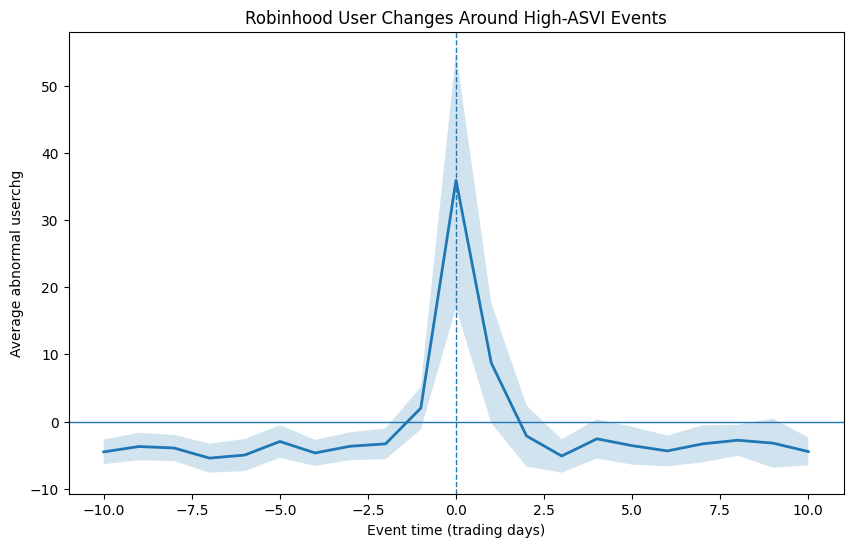

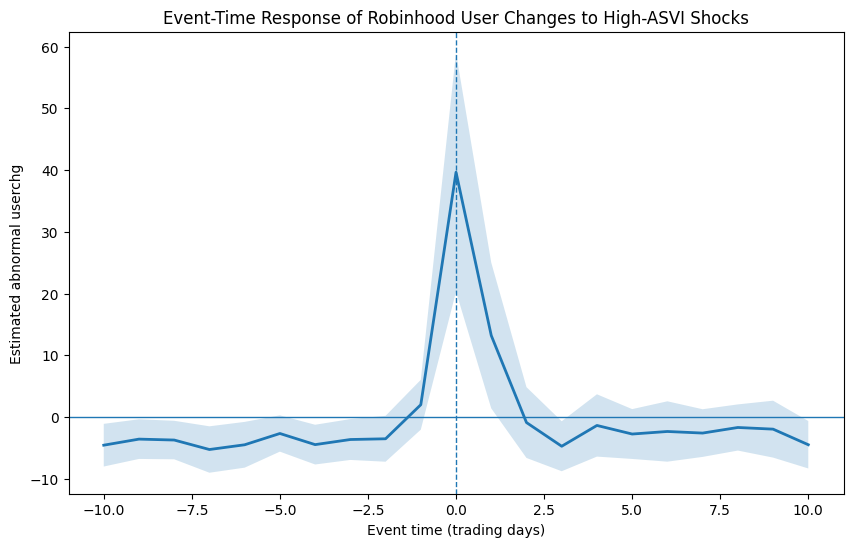

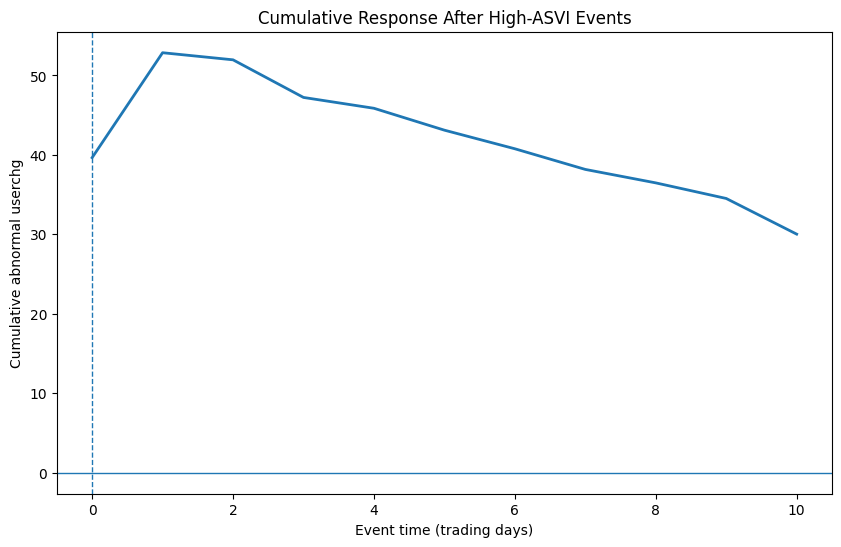

In [24]:
# ============================================================
# 1. PREPARE PANEL
# ============================================================

df = main.copy()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
df = df.dropna(subset=['ticker', 'date', 'userchg', 'intraday_userchg', 'svi']).copy()

# correct value for intraday_userchg
df['intraday_userchg'] *= -1

# build contemporaneous abnormal SVI
def make_ab_svi(s):
    mu = s.shift(1).rolling(window=20, min_periods=20).mean()
    ratio = s / mu
    ratio[(mu <= 0) | (~np.isfinite(ratio))] = np.nan
    return np.log1p(ratio)

df['asvi_t'] = df.groupby('ticker')['svi'].transform(make_ab_svi)

# keep stocks with enough data
stock_counts = df.groupby('ticker')['date'].transform('count')
df = df[stock_counts >= 60].copy()

# trading-time index within stock
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
df['td_index'] = df.groupby('ticker').cumcount()

# ============================================================
# 2. DEFINE HIGH-ASVI EVENTS
# ============================================================

df['asvi_p99_stock'] = df.groupby('ticker')['asvi_t'].transform(
    lambda x: x.quantile(0.99)
)

df['event_candidate'] = (
    (df['asvi_t'] >= df['asvi_p99_stock']) &
    (df['asvi_p99_stock'] > 0) &
    (df['asvi_t'] > 0)
).astype(int)

df['event_onset'] = (
    (df['event_candidate'] == 1) &
    (df.groupby('ticker')['event_candidate'].shift(1).fillna(0) == 0)
).astype(int)

# ============================================================
# 3. ENFORCE NON-OVERLAP
# ============================================================

event_window = 10
min_gap = 2 * event_window + 1   # 21 trading days

def keep_non_overlapping_events(g, min_gap):
    g = g.sort_values('td_index').copy()
    event_positions = g.loc[g['event_onset'] == 1, 'td_index'].tolist()

    keep = []
    last_kept = -np.inf
    for pos in event_positions:
        if pos - last_kept >= min_gap:
            keep.append(pos)
            last_kept = pos

    g['event_keep'] = g['td_index'].isin(keep).astype(int)
    return g

df = df.groupby('ticker', group_keys=False).apply(
    keep_non_overlapping_events,
    min_gap=min_gap
)

# ============================================================
# 4. RESIDUALIZE USERCHG WITH STOCK AND DATE FE
# ============================================================

df_fe = df.set_index(['ticker', 'date']).sort_index()

y = df_fe['userchg']
X = pd.DataFrame({'const': 1.0}, index=df_fe.index)

fe_model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

fe_res = fe_model.fit()
df_fe['userchg_abn'] = fe_res.resids
df = df_fe.reset_index()

# ============================================================
# 5. BUILD EVENT-TIME PANEL
# ============================================================

window_list = []

for ticker, g in df.groupby('ticker'):
    g = g.sort_values('td_index').reset_index(drop=True)
    event_rows = g.index[g['event_keep'] == 1].tolist()

    for row_idx in event_rows:
        event_td = g.loc[row_idx, 'td_index']
        event_date = g.loc[row_idx, 'date']

        lower_td = event_td - event_window
        upper_td = event_td + event_window

        win = g[(g['td_index'] >= lower_td) & (g['td_index'] <= upper_td)].copy()
        win['event_time'] = win['td_index'] - event_td
        win['event_id'] = f"{ticker}_{event_date.strftime('%Y%m%d')}"
        win['event_ticker'] = ticker
        win['event_date'] = event_date

        window_list.append(
            win[['event_id', 'event_ticker', 'event_date', 'date',
                 'event_time', 'userchg', 'userchg_abn', 'asvi_t']]
        )

event_panel = pd.concat(window_list, ignore_index=True)

# keep only complete windows
complete_counts = event_panel.groupby('event_id')['event_time'].nunique()
complete_ids = complete_counts[complete_counts == (2 * event_window + 1)].index
event_panel_bal = event_panel[event_panel['event_id'].isin(complete_ids)].copy()

# ============================================================
# 6. EVENT-TIME AVERAGES
# ============================================================

avg_path = (
    event_panel_bal
    .groupby('event_time')
    .agg(
        avg_userchg=('userchg', 'mean'),
        avg_userchg_abn=('userchg_abn', 'mean'),
        sd_userchg_abn=('userchg_abn', 'std'),
        n_events=('event_id', 'nunique')
    )
    .reset_index()
    .sort_values('event_time')
)

avg_path['se_userchg_abn'] = avg_path['sd_userchg_abn'] / np.sqrt(avg_path['n_events'])
avg_path['ci_low'] = avg_path['avg_userchg_abn'] - 1.96 * avg_path['se_userchg_abn']
avg_path['ci_high'] = avg_path['avg_userchg_abn'] + 1.96 * avg_path['se_userchg_abn']

avg_path['cum_avg_userchg_abn'] = np.nan
mask = avg_path['event_time'] >= 0
avg_path.loc[mask, 'cum_avg_userchg_abn'] = avg_path.loc[mask, 'avg_userchg_abn'].cumsum()

print(avg_path)

# ============================================================
# 7. LOCAL-PROJECTION EVENT-STUDY ESTIMATES
#    beta_h = average abnormal userchg at horizon h after event onset
# ============================================================

# Align outcomes at horizon h back to event date t
lp_df = df.copy()

# event indicator on event date t
lp_df['event_keep'] = lp_df['event_keep'].astype(int)

# clustering variables
lp_df['ticker_clust'] = lp_df['ticker'].astype('category').cat.codes
lp_df['date_clust'] = lp_df['date'].astype('category').cat.codes

horizons = list(range(-event_window, event_window + 1))
lp_results = []

for h in horizons:
    temp = lp_df[['ticker', 'date', 'userchg_abn', 'event_keep',
                  'ticker_clust', 'date_clust']].copy()

    # outcome at t+h, aligned to row t
    temp['y_h'] = temp.groupby('ticker')['userchg_abn'].shift(-h)

    temp = temp.dropna(subset=['y_h', 'event_keep']).copy()

    X = sm.add_constant(temp[['event_keep']])
    y = temp['y_h']

    res = sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': temp[['ticker_clust', 'date_clust']]}
    )

    beta = res.params['event_keep']
    se = res.bse['event_keep']

    lp_results.append({
        'event_time': h,
        'beta': beta,
        'se': se,
        'ci_low': beta - 1.96 * se,
        'ci_high': beta + 1.96 * se,
        'n_obs': len(temp)
    })

lp_results = pd.DataFrame(lp_results).sort_values('event_time').copy()
lp_results['cum_beta'] = np.nan

mask = lp_results['event_time'] >= 0
lp_results.loc[mask, 'cum_beta'] = lp_results.loc[mask, 'beta'].cumsum()

print(lp_results)

# ============================================================
# 8. PLOTS
# ============================================================

# Average abnormal userchg around event
plt.figure(figsize=(10, 6))
plt.plot(avg_path['event_time'], avg_path['avg_userchg_abn'], linewidth=2)
plt.fill_between(
    avg_path['event_time'],
    avg_path['ci_low'],
    avg_path['ci_high'],
    alpha=0.2
)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Average abnormal userchg')
plt.title('Robinhood User Changes Around High-ASVI Events')
plt.show()

# Local-projection estimates with clustered SEs
plt.figure(figsize=(10, 6))
plt.plot(lp_results['event_time'], lp_results['beta'], linewidth=2)
plt.fill_between(
    lp_results['event_time'],
    lp_results['ci_low'],
    lp_results['ci_high'],
    alpha=0.2
)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Estimated abnormal userchg')
plt.title('Event-Time Response of Robinhood User Changes to High-ASVI Shocks')
plt.show()

# Cumulative abnormal response
plt.figure(figsize=(10, 6))
cum_df = lp_results[lp_results['event_time'] >= 0].copy()
plt.plot(cum_df['event_time'], cum_df['cum_beta'], linewidth=2)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Cumulative abnormal userchg')
plt.title('Cumulative Response After High-ASVI Events')
plt.show()

#### Comments

These figures support one clear and fairly strong conclusion: high contemporaneous ASVI episodes are associated with a sharp, short-lived surge in abnormal Robinhood user inflows on the event day, followed by rapid normalization and then mild reversal over the subsequent trading days. That pattern is visible in both the simple event-time averages and the local-projection estimates, which is reassuring. It is also economically consistent with the attention-induced trading mechanism in which retail attention generates temporary buying pressure rather than persistent demand. Da, Engelberg, and Gao argue that abnormal search attention should produce short-run price pressure and later reversal, and Barber et al. document that intense Robinhood buying around attention-driven episodes forecasts negative subsequent returns.  ￼

The cleanest reading of these first two panels is this. Before the event, abnormal *userchg* is slightly negative and fairly stable. At event time 0, it jumps very sharply, to roughly 40 abnormal users. At event time +1, it remains positive but much smaller. By about +2, the effect is already close to zero, and from about +3 onward the path is mildly negative. That is not a gradual buildup of retail participation. It is a burst-and-fade pattern. The fact that the local-projection figure looks nearly identical to the raw event-time average strengthens the descriptive conclusion, because it suggests the shape is not an artifact of the simple averaging procedure alone.

The cumulative plot adds an important nuance. The post-event cumulative abnormal *userchg* remains positive even ten trading days later, although it decays materially from its initial peak. So the right statement is not that the event fully reverses in holdings space over the next ten days. Rather, there is a large immediate inflow, followed by partial unwind. In other words, high-ASVI shocks appear to attract Robinhood users quickly, but the induced increase in holders is not fully permanent and begins to erode soon after the event. That distinction matters. In returns, the literature emphasizes temporary price pressure and reversal. In holdings, one should expect weaker and slower reversal because some investors who buy do not immediately exit. ￼

So the most defensible substantive conclusion is this: contemporaneous spikes in Google-search-based attention coincide with substantial **same-day** abnormal growth in Robinhood ownership, and this attention-driven demand effect is highly transitory in flow terms. The event-day effect is large; the incremental effect after day +1 is small to negative. This is exactly the type of dynamic one would expect if attention shocks mobilize retail buying quickly and then fade. It is also aligned with later evidence that retail attention is associated with contemporaneous buying pressure and subsequent correction.  ￼

What we should not claim from these figures is causality. This is still an event study around endogenous attention realizations, not around exogenous shocks. High ASVI may reflect the market reacting to news, price moves, social media, or platform salience. The event study establishes a tight dynamic association, not an exogenous treatment effect. That caveat is important if I want this to read like top-field empirical work.

There is a second caution. My event date is defined using contemporaneous $\text{asvi}_t$, which is built from the same day’s SVI relative to the trailing 20-day mean. That improves the timing relative to my earlier lagged-ASVI exercise, but it also means event time 0 is the day on which attention is already abnormally high. **So the spike at day 0 is best interpreted as a contemporaneous response, not as a predictive effect**. This distinction reconciles my earlier panel regressions: lagged ASVI could turn weak or negative once lagged user changes are included, while contemporaneous high-ASVI events can still be associated with a strong same-day inflow. The dynamic story is then coherent: attention shocks and Robinhood inflows occur together on impact, and most of the action is absorbed immediately rather than with a long delay.

Methodologically, the figures are credible enough to report as an event-time characterization, but I would still tighten three things before treating them as final. First, the confidence bands in the first panel are constructed from simple cross-event dispersion, whereas the second panel uses two-way clustered inference. For the paper, the local-projection figure is the more defensible inferential object. Second, because ASVI is defined as an extreme within-stock percentile event, I should report the number of retained events explicitly in the figure note or text. Third, I would show robustness to an alternative event threshold, such as the within-stock top 5% instead of top 1%. If the burst-and-fade shape survives, the interpretation becomes much stronger.

#### CORE MESSAGE

High ASVI is strongly associated with same-day abnormal Robinhood user inflows, but this event-study design does not establish that the Google searches themselves cause the inflows. More plausibly, both are jointly driven by some underlying attention trigger, such as news, extreme price moves, social media discussion, or platform salience. This is exactly why the attention literature distinguishes between direct measures of attention and the underlying sources of attention. Da et al. argue that search data are a more direct measure of investor attention than news or returns, but even then, the search itself is still a manifestation of attention, not necessarily its ultimate origin.

For an investor to search for a stock by name or ticker, the stock has usually already entered that investor’s consideration set somehow. That "somehow" may be a news item, a large return, Reddit, the Robinhood Top Movers list, or word of mouth. Barber and Odean’s core idea is exactly that attention first narrows the choice set, and only then do investors decide whether to buy.  Robinhood-specific features can also create that initial salience: Barber et al. show that the app’s Top Movers display affects Robinhood user behavior, which means the platform itself can be a source of the attention shock that later shows up in Google searches and trading.

## 5. External Validity

To assess whether the results are specific to Robinhood-based holdings changes or instead generalize to broader retail trading activity, I re-estimate the baseline specification using TAQ-based retail net buys as the dependent variable. Because the TAQ and Robintrack measures capture distinct but related dimensions of retail participation, similar coefficient patterns across the two specifications would support the external validity of the Robinhood-based findings.

In [25]:
reg5 = df_reg_1.copy().dropna(subset=['net_buys', 'top_20', 'ab_vol_lag1',
                                      'net_buys_lag1', 'asvi', 'num_news_lag1',
                                      'num_news_relevant_lag1',
                                      'ess_lag1', 'css_lag1', 'anl_chg_lag1'])

# make sure date is datetime
reg5['date'] = pd.to_datetime(reg5['date'])

# convert clusters to integer codes
reg5['ticker_clust'] = reg5['ticker'].astype('category').cat.codes
reg5['date_clust'] = reg5['date'].astype('category').cat.codes

X5 = sm.add_constant(reg5[['top_20', 'ab_vol_lag1', 'net_buys_lag1', 'asvi', 'num_news_lag1',
                           'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1' ]])
y5 = reg5['net_buys']

results5 = OLS(y5, X5).fit(
    cov_type='clustered',
    clusters=reg5[['ticker_clust', 'date_clust']]
)

print(results5.summary)

                            OLS Estimation Summary                            
Dep. Variable:               net_buys   R-squared:                      0.4811
Estimator:                        OLS   Adj. R-squared:                 0.4811
No. Observations:             1041283   F-statistic:                    621.43
Date:                Sun, Mar 29 2026   P-value (F-stat)                0.0000
Time:                        00:32:21   Distribution:                  chi2(9)
Cov. Estimator:             clustered                                         
                                                                              
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
const                      19.010     2.8900     6.5779     0.0000      13.346      24.675
top_

In [26]:
reg5_a = df_reg_1.copy().dropna(subset=['net_buys', 'top_20', 'ab_vol_lag1',
                                      'net_buys_lag1', 'asvi', 'num_news_lag1',
                                      'num_news_relevant_lag1',
                                      'ess_lag1', 'css_lag1', 'anl_chg_lag1'])

# make sure date is datetime
reg5_a['date'] = pd.to_datetime(reg5_a['date'])

# set panel index: entity = ticker, time = date
reg5_a = reg5_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y5a = reg5_a['net_buys']

# regressors: do NOT add a constant when using both entity and time fixed effects
X5a = reg5_a[[
    'top_20', 'ab_vol_lag1', 'net_buys_lag1', 'asvi', 'num_news_lag1',
    'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1'
]]

# estimate with stock and date fixed effects
model5a = PanelOLS(
    y5a,
    X5a,
    entity_effects=True,   # stock fixed effects
    time_effects=True      # date fixed effects
)

results5a = model5a.fit(
    cov_type='clustered',
    cluster_entity=True,   # cluster by stock
    cluster_time=True      # cluster by date
)
print(results5a.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23417/1731716927.py:29: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results5a = model5a.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:               net_buys   R-squared:                        0.4174
Estimator:                   PanelOLS   R-squared (Between):              0.8581
No. Observations:             1041283   R-squared (Within):               0.4216
Date:                Sun, Mar 29 2026   R-squared (Overall):              0.4784
Time:                        00:32:25   Log-likelihood                -7.484e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   8.269e+04
Entities:                        1978   P-value                           0.0000
Avg Obs:                       526.43   Distribution:               F(9,1038739)
Min Obs:                       2.0000                                           
Max Obs:                       558.00   F-statistic (robust):             31.603
                            